# COVID-19 Data Analysis and Visualization

Analyzing the spread of COVID-19 across countries and continents — looking at total cases, recoveries, deaths, and testing, and visualizing how countries compare.


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the Dataset

In [4]:
df = pd.read_csv("covid_19.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN


In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (238, 9)


In [6]:
print(df.columns)

Index(['country', 'continent', 'population', 'day', 'time', 'Cases', 'Recovered', 'Deaths', 'Tests'], dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    str    
 1   continent   236 non-null    str    
 2   population  229 non-null    float64
 3   day         238 non-null    str    
 4   time        238 non-null    str    
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 16.9 KB


In [8]:
df.describe()

,population,Cases,Recovered,Deaths,Tests
count,2.290000e+02,2.380000e+02,1.900000e+02,2.330000e+02,2.130000e+02
mean,3.469404e+07,8.883449e+06,1.006214e+07,9.026621e+04,3.298829e+07
std,1.386374e+08,5.193031e+07,5.555519e+07,5.163434e+05,1.198779e+08
min,7.990000e+02,9.000000e+00,2.000000e+00,1.000000e+00,7.850000e+03
25%,4.454310e+05,2.741875e+04,2.197250e+04,2.250000e+02,3.478150e+05
50%,5.797805e+06,2.320425e+05,2.351455e+05,2.570000e+03,2.226216e+06
75%,2.210284e+07,1.565481e+06,2.078212e+06,1.805700e+04,1.346373e+07
max,1.448471e+09,7.047539e+08,6.756198e+08,7.010681e+06,1.186852e+09


**Insight:** Dataset mein `Cases`, `Recovered`, `Deaths` aur `Tests` ka scale bahut alag-alag hai (kuch countries mein sirf 9 cases, jabki max ~70 crore tak). Mean values std deviation se kaafi kam hain, matlab distribution heavily right-skewed hai — chand bade countries hi total numbers ko dominate kar rahe hain.

## 3. Check and Handle Missing Values

In [10]:
df.isnull().sum()

country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64

In [11]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
# Recovered, Deaths and Tests have missing values for some countries — fill with 0
df["Recovered"] = df["Recovered"].fillna(0)
df["Deaths"] = df["Deaths"].fillna(0)
df["Tests"] = df["Tests"].fillna(0)

df.isnull().sum()

country       0
continent     2
population    9
day           0
time          0
Cases         0
Recovered     0
Deaths        0
Tests         0
dtype: int64

**Insight:** `Recovered`, `Deaths` aur `Tests` columns mein missing values thay (jaise 48 countries ke liye Recovered data nahi tha) — inhe 0 se fill kiya gaya, matlab un countries ne ya to data report nahi kiya ya waha recovery/death/testing na ke barabar hua. `continent` aur `population` mein bhi thodi missing values hain jo baad ke per-capita analysis mein kuch rows ko automatically exclude kar dengi.

## 4. Separate Country-Level Data from Continent-Level Summaries

The dataset already contains continent-wise (and a global "All") summary rows, where the `country` column equals a continent name. We split these out so we can analyze countries and continents separately.

In [14]:
continent_labels = ["Africa", "South-America", "North-America", "Europe", "Asia", "Oceania", "All"]

continent_df = df[df["country"].isin(continent_labels)].copy()
country_df = df[~df["country"].isin(continent_labels)].copy()

print("Continent/global summary rows:", continent_df.shape[0])
print("Country-level rows:", country_df.shape[0])

Continent/global summary rows: 7
Country-level rows: 231


In [15]:
continent_df[["country", "Cases", "Recovered", "Deaths"]]

,country,Cases,Recovered,Deaths
212,North-America,131889132,127665129.0,1695941.0
213,Asia,221500265,205673091.0,1553662.0
214,Europe,253406198,248754104.0,2101824.0
215,South-America,70200879,66683585.0,1367332.0
216,Oceania,14895771,14752388.0,33015.0
217,Africa,12860924,12090808.0,258892.0
218,All,704753890,675619811.0,7010681.0


**Insight:** Continent-wise summary rows already dataset mein diye gaye the, isliye unhe alag karke pehle country-level aur continent-level analysis clean ho gaya. Isse double-counting (jaise continent total ko individual country jaisa treat karna) avoid ho gaya.

## 5. Global Snapshot

In [17]:
global_row = continent_df[continent_df["country"] == "All"].iloc[0]

print("GLOBAL COVID-19 SNAPSHOT")
print("Total Cases:     {:,.0f}".format(global_row["Cases"]))
print("Total Recovered: {:,.0f}".format(global_row["Recovered"]))
print("Total Deaths:    {:,.0f}".format(global_row["Deaths"]))
print("Global Death Rate: {:.2f}%".format(global_row["Deaths"] / global_row["Cases"] * 100))
print("Global Recovery Rate: {:.2f}%".format(global_row["Recovered"] / global_row["Cases"] * 100))

GLOBAL COVID-19 SNAPSHOT
Total Cases:     704,753,890
Total Recovered: 675,619,811
Total Deaths:    7,010,681
Global Death Rate: 0.99%
Global Recovery Rate: 95.87%


**Insight:** Global level par Recovery Rate (95.87%) death rate (0.99%) se kaafi zyada hai — matlab COVID overall highly recoverable raha, lekin absolute deaths (~70 lakh) phir bhi bahut zyada hain kyunki total cases hi 70 crore+ the. Chhoti percentage bhi bade base par bade numbers bana deti hai.

## 6. Continent-Wise Comparison

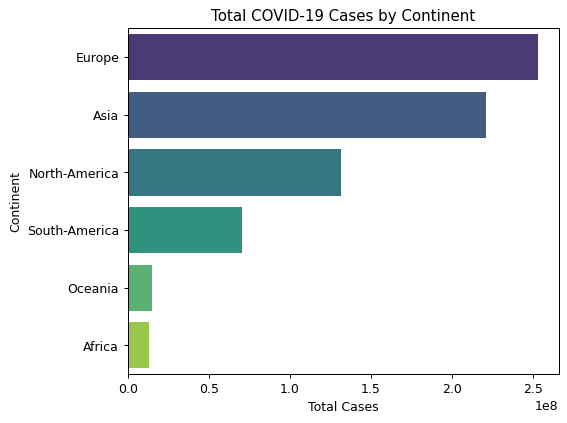

In [19]:
continent_only = continent_df[continent_df["country"] != "All"].sort_values("Cases", ascending=False)

fig, ax = plt.subplots()
sns.barplot(data=continent_only, x="Cases", y="country", hue="country", palette="viridis", legend=False, ax=ax)
ax.set_title("Total COVID-19 Cases by Continent")
ax.set_xlabel("Total Cases")
ax.set_ylabel("Continent")
plt.tight_layout()
plt.show()

**Insight:** Europe aur Asia total cases ke hisaab se sabse aage hain, North-America aur South-America unke baad. Oceania aur Africa sabse kam cases dikhate hain — yeh population density, testing capacity aur reporting standards ke antar ko reflect kar sakta hai, sirf actual spread ka nahi.

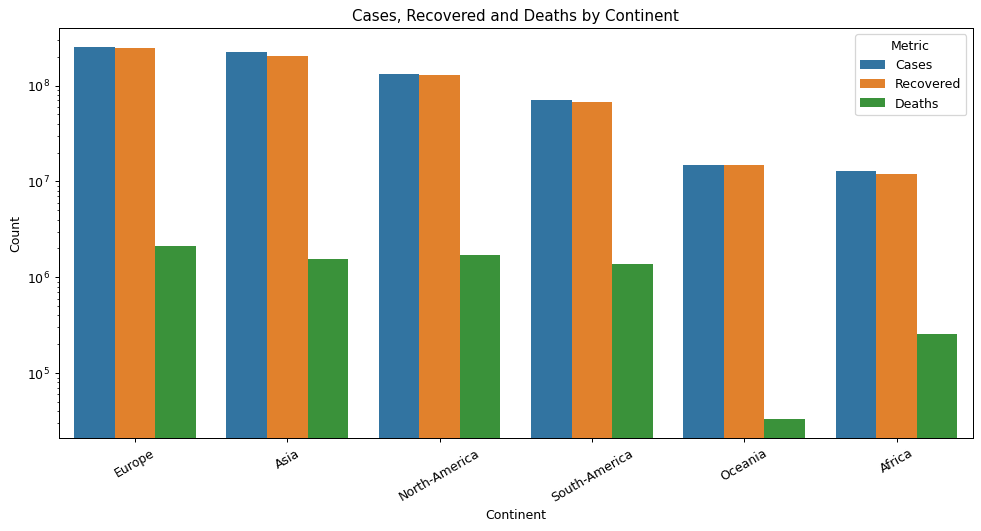

In [20]:
# Cases vs Deaths vs Recovered per continent
melted = continent_only.melt(id_vars="country", value_vars=["Cases", "Recovered", "Deaths"],
                              var_name="Metric", value_name="Count")

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=melted, x="country", y="Count", hue="Metric", ax=ax)
ax.set_title("Cases, Recovered and Deaths by Continent")
ax.set_xlabel("Continent")
ax.set_yscale("log")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Insight:** Log scale par dekhne se pata chalta hai ki har continent mein Recovered, Cases ke bahut close hai (high recovery trend consistent hai across continents), jabki Deaths sabse chhota bar hai — yani mortality globally low rahi hai relative to infections, chahe continent koi bhi ho.

In [ ]:
fig = px.pie(continent_only, names="country", values="Cases",
             title="Share of Global COVID-19 Cases by Continent", hole=0.4)
fig.show()

**Insight:** Pie chart se global cases ka distribution continent-wise clear hota hai — Europe aur Asia milkar total cases ka bada hissa cover karte hain, jabki Africa aur Oceania ka contribution bahut chhota hai. Yeh unequal share population size aur testing infrastructure dono se judi ho sakti hai.

## 7. Top 10 Countries by Total Cases

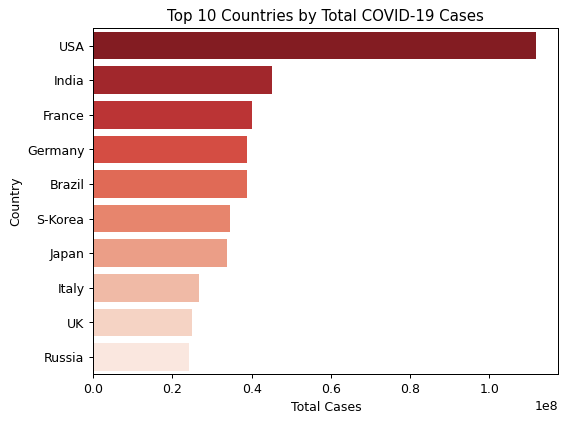

In [23]:
top_cases = country_df.sort_values("Cases", ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(data=top_cases, x="Cases", y="country", hue="country", palette="Reds_r", legend=False, ax=ax)
ax.set_title("Top 10 Countries by Total COVID-19 Cases")
ax.set_xlabel("Total Cases")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

**Insight:** Top 10 countries by total cases mein typically bade population wale countries (jaise US, India, Brazil, France, Germany type large-population nations) dominate karte hain — kyunki raw case count population se directly correlated hota hai, chhote countries yahan nazar nahi aate chahe unka per-capita spread zyada ho.

## 8. Top 10 Countries by Total Deaths

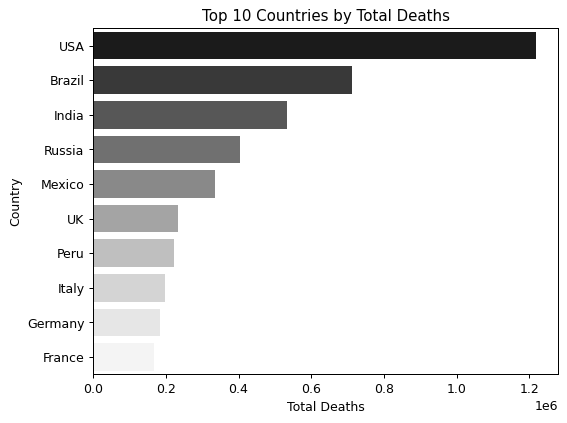

In [25]:
top_deaths = country_df.sort_values("Deaths", ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(data=top_deaths, x="Deaths", y="country", hue="country", palette="Greys_r", legend=False, ax=ax)
ax.set_title("Top 10 Countries by Total Deaths")
ax.set_xlabel("Total Deaths")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

**Insight:** Total deaths ki list bhi largely bade population/high-case countries se match karti hai, lekin ranking cases ki ranking se thodi alag hai — kuch countries jinke cases zyada the unki healthcare capacity ya age demographics ki wajah se death toll relatively kam raha, aur kuch mein zyada.

## 9. Death Rate and Recovery Rate by Country

We compute the death rate (`Deaths / Cases`) and recovery rate (`Recovered / Cases`) for countries with a meaningful number of cases, so small outbreaks don't distort the ranking.

In [27]:
analysis_df = country_df[country_df["Cases"] > 10000].copy()

analysis_df["Death_Rate_%"] = (analysis_df["Deaths"] / analysis_df["Cases"] * 100).round(2)
analysis_df["Recovery_Rate_%"] = (analysis_df["Recovered"] / analysis_df["Cases"] * 100).round(2)

analysis_df[["country", "continent", "Cases", "Death_Rate_%", "Recovery_Rate_%"]].sort_values("Death_Rate_%", ascending=False).head(10)

,country,continent,Cases,Death_Rate_%,Recovery_Rate_%
46,Yemen,Asia,11945,18.07,76.38
66,Sudan,Africa,63993,7.89,92.11
69,Syria,Asia,57743,5.48,94.52
60,Somalia,Africa,27334,4.98,48.23
181,Peru,South-America,4572667,4.86,95.14
119,Egypt,Africa,516023,4.77,85.69
235,Mexico,North-America,7702809,4.35,89.58
146,Bosnia-and-Herzegovina,Europe,403615,4.06,93.92
159,Afghanistan,Asia,234174,3.41,90.14
122,Ecuador,South-America,1070188,3.37,96.63


**Insight:** Death rate ke hisaab se top countries (Yemen ~18%, Sudan ~7.9%, Syria ~5.5%) mostly wahi hain jo conflict-affected ya weak healthcare infrastructure wale hain — high death rate ka matlab zyada spread nahi, balki poor testing/healthcare capacity bhi ho sakta hai (kam testing => sirf severe cases hi report hote hain => death rate artificially high dikhta hai).

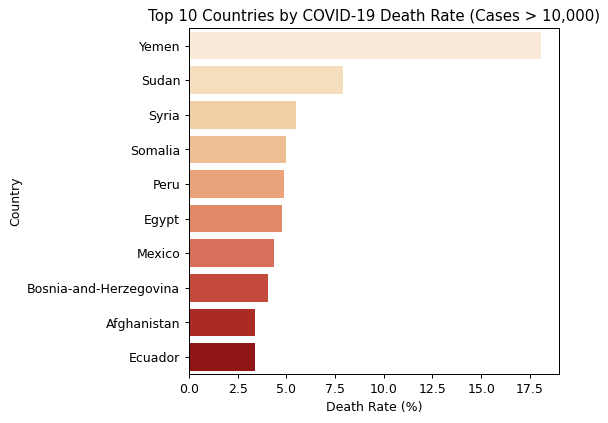

In [28]:
top_death_rate = analysis_df.sort_values("Death_Rate_%", ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(data=top_death_rate, x="Death_Rate_%", y="country", hue="country", palette="OrRd", legend=False, ax=ax)
ax.set_title("Top 10 Countries by COVID-19 Death Rate (Cases > 10,000)")
ax.set_xlabel("Death Rate (%)")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

**Insight:** Yeh chart clearly dikhata hai ki high death rate wale countries zaroori nahi ki high case-count wale countries hon (jaise Yemen, Sudan, Syria ka case count 10k-64k range mein hi hai) — death rate aur case volume do alag dimensions hain jo healthcare infrastructure ki quality reflect karte hain.

## 10. Cases per Million Population

Raw case counts favor large countries. Normalizing by population gives a fairer picture of how hard each country was hit.

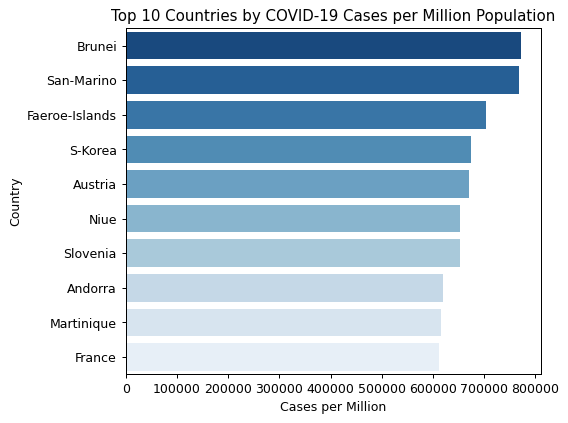

In [30]:
pop_df = country_df[country_df["population"] > 0].copy()
pop_df["Cases_per_Million"] = (pop_df["Cases"] / pop_df["population"] * 1_000_000).round(0)

top_per_capita = pop_df.sort_values("Cases_per_Million", ascending=False).head(10)

fig, ax = plt.subplots()
sns.barplot(data=top_per_capita, x="Cases_per_Million", y="country", hue="country", palette="Blues_r", legend=False, ax=ax)
ax.set_title("Top 10 Countries by COVID-19 Cases per Million Population")
ax.set_xlabel("Cases per Million")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

**Insight:** Population-normalize karne ke baad ranking completely badal jaati hai — chhote countries (jinka absolute case count kam tha) per-million basis par top par aa jaate hain. Yeh confirm karta hai ki raw case count sirf population size ka proxy tha, actual per-capita impact alag story batata hai.

## 11. Testing vs Cases

Does more testing correlate with more reported cases? We check this for countries that report testing data.

In [ ]:
tested_df = country_df[country_df["Tests"] > 0]

fig = px.scatter(tested_df, x="Tests", y="Cases", size="population", color="continent",
                  hover_name="country", log_x=True, log_y=True,
                  title="Tests vs Reported Cases by Country (log scale, bubble size = population)")
fig.show()

**Insight:** Tests aur Cases ke beech positive correlation dikhta hai (log-log scale par) — jitni zyada testing hui, utne zyada cases report hue. Iska matlab hai ki actual case numbers largely testing capacity se bhi limited/driven the, na ki sirf actual infection spread se — kam testing wale countries ke case numbers underreported ho sakte hain.

## 12. Correlation Between Numeric Variables

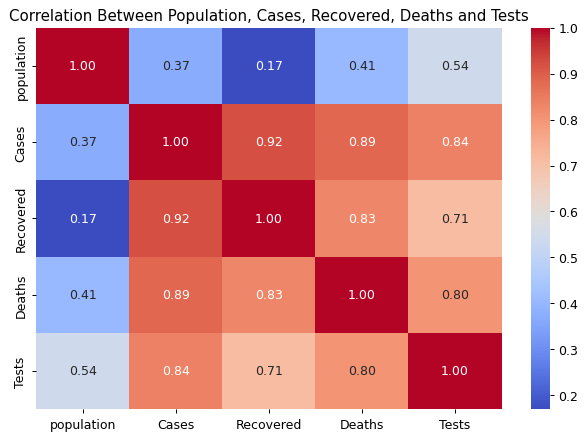

In [34]:
numeric_cols = ["population", "Cases", "Recovered", "Deaths", "Tests"]
corr = country_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Between Population, Cases, Recovered, Deaths and Tests")
plt.tight_layout()
plt.show()

**Insight:** Correlation heatmap se pata chalta hai ki Cases, Recovered aur Tests aapas mein strongly positively correlated hain (jyada testing → jyada cases → jyada recoveries), jabki Deaths ka correlation thoda weaker hai in sabse — confirm karta hai ki death outcome sirf case volume par nahi, healthcare quality jaise external factors par bhi depend karta hai. Population ka bhi Cases/Tests ke saath positive correlation hai, jo expected hai (bade countries mein zyada log = zyada cases/tests).

## 13. Key Insights Summary

- Global recovery rate (~95.9%) death rate (~0.99%) se kaafi zyada hai, lekin absolute deaths bade base ki wajah se ~70 lakh tak pahunch gaye.
- **Europe aur Asia** total cases mein sabse aage hain; **Africa aur Oceania** sabse kam — yeh spread se zyada testing/reporting capacity ka farak dikhata hai.
- Raw case/death counts largely **population size** se driven hain — jab tak per-million normalize nahi karte, badi rankings sirf bade countries dikhati hain.
- Sabse zyada **death rate** wale countries (Yemen, Sudan, Syria) high case-volume wale nahi hain — weak healthcare infrastructure aur low testing high death rate ka bada reason ho sakta hai.
- **Testing aur Cases** ke beech strong positive correlation confirm karta hai ki reported case numbers testing capacity se limited the, actual spread se nahi.
- Correlation heatmap ke mutabik Deaths, Cases/Tests se weaker correlated hain — matlab mortality outcome healthcare quality jaisi factors par zyada depend karta hai, sirf infection volume par nahi.
